# Step 2: The baseline lock exchange

How much numerical mixing does Oceananigans' high-order scheme (WENO, 5th order) create in the standard lock exchange, and does the flow itself behave as theory says? I ran `simulations/run_step2.jl`: dx = 500 m, dz = 1 m (128 x 20 cells), lateral viscosity 1e-2 m^2/s and vertical viscosity 1e-4 m^2/s as in Ilicak et al. (2012), zero tracer diffusivity, WENO for buoyancy and momentum, 17 model hours.

I load the libraries and the shared analysis functions (`mixing_tools.py`, in this folder), and set the parameters.

In [1]:
%matplotlib inline

import os

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from mixing_tools import (DELTA_B, DEPTH, LENGTH, load_run, rpe_series, buoyancy_variance, front_positions,
                          front_speed, rpe_rate_at)

RUN = "step2_baseline_weno"
SNAPSHOT_HOURS = [0, 4, 8, 12, 17]          # times to plot (h)
FIT_START, FIT_END = 3 * 3600, 15 * 3600     # time window for the front-speed fit (s), after start-up, before the walls
RATE_WINDOW = 3600                           # window for dRPE/dt at 17 h (s)
FIG_DIR = "../figures"
DATA_DIR = "../data"

ds, log, info = load_run(RUN)
times = ds.time.values
print(f"{RUN}: {info['status']}, {info['iterations']} iterations, wall time {info['wall_time_s']} s, "
      f"{ds.sizes['time']} snapshots, grid {info['Nx']} x {info['Nz']}")

step2_baseline_weno: completed, 1907 iterations, wall time 21.26 s, 103 snapshots, grid 128 x 20


Buoyancy at five times. The dense water (blue) should slide under the light water (red) as a gravity current to the right, and the light water over it to the left.

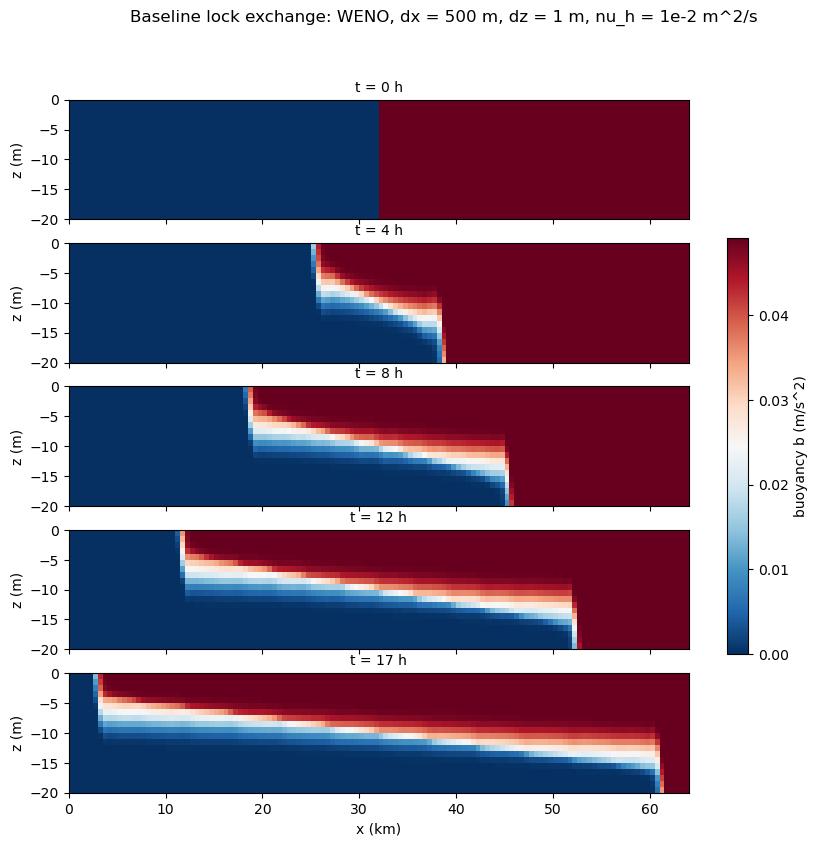

In [2]:
x_km = ds.x_caa / 1e3
fig, axes = plt.subplots(len(SNAPSHOT_HOURS), 1, figsize=(10, 9), sharex=True)
for ax, hours in zip(axes, SNAPSHOT_HOURS):
    snapshot = ds["b"].sel(time=hours * 3600, method="nearest")
    mesh = ax.pcolormesh(x_km, ds.z_aac, snapshot, cmap="RdBu_r", vmin=0, vmax=DELTA_B, shading="nearest")
    ax.set_ylabel("z (m)")
    ax.set_title(f"t = {hours} h", fontsize=10)
axes[-1].set_xlabel("x (km)")
fig.colorbar(mesh, ax=axes, label="buoyancy b (m/s^2)", shrink=0.6)
fig.suptitle("Baseline lock exchange: WENO, dx = 500 m, dz = 1 m, nu_h = 1e-2 m^2/s")
fig.savefig(os.path.join(FIG_DIR, "02_baseline_snapshots.png"), dpi=150, bbox_inches="tight")
plt.show()

## Front speed

Benjamin (1968): a gravity current in a channel of depth H moves at u_f = 0.5 sqrt(g' H), where g' = g dρ/ρ0 is the reduced gravity (here the buoyancy difference, 0.04905 m/s^2). The idea: the dense water's extra weight is converted into motion, and for an energy-conserving current that fills half the depth the speed comes out as half of sqrt(g' H). I track each nose and fit a straight line between 3 and 15 hours. (The two currents turn out to be exact mirror images, because in this Boussinesq setup light water rising behaves exactly like dense water sinking, so the two lines in the plot lie on top of each other. The steps come from the 500 m grid.)

theory 0.5 sqrt(g' H) = 0.4952 m/s
dense current (bottom, to the right): 0.4793 m/s (-3.2%)
light current (top, to the left):     0.4793 m/s (-3.2%)
positions at 17 h: dense nose 60.75 km, light nose 3.25 km (walls at 0 and 64 km)


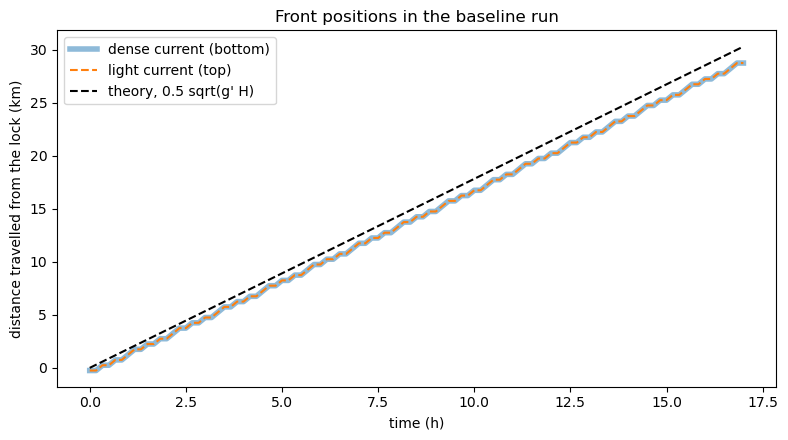

In [3]:
right, left = front_positions(ds)
u_theory = 0.5 * np.sqrt(DELTA_B * DEPTH)
u_right = front_speed(times, right, FIT_START, FIT_END)
u_left = -front_speed(times, left, FIT_START, FIT_END)
print(f"theory 0.5 sqrt(g' H) = {u_theory:.4f} m/s")
print(f"dense current (bottom, to the right): {u_right:.4f} m/s ({100 * (u_right / u_theory - 1):+.1f}%)")
print(f"light current (top, to the left):     {u_left:.4f} m/s ({100 * (u_left / u_theory - 1):+.1f}%)")
print(f"positions at 17 h: dense nose {right[-1] / 1e3:.2f} km, light nose {left[-1] / 1e3:.2f} km (walls at 0 and 64 km)")

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(times / 3600, (right - LENGTH / 2) / 1e3, "-", lw=4, alpha=0.5, color="tab:blue", label="dense current (bottom)")
ax.plot(times / 3600, (LENGTH / 2 - left) / 1e3, "--", lw=1.5, color="tab:orange", label="light current (top)")
ax.plot(times / 3600, u_theory * times / 1e3, "k--", label="theory, 0.5 sqrt(g' H)")
ax.set_xlabel("time (h)")
ax.set_ylabel("distance travelled from the lock (km)")
ax.set_title("Front positions in the baseline run")
ax.legend()
fig.tight_layout()
fig.savefig(os.path.join(FIG_DIR, "02_baseline_front_position.png"), dpi=150)
plt.show()

## Reference potential energy and buoyancy variance

RPE (Winters et al. 1995): take all the water and rearrange it, without mixing, into the most stable state, densest at the bottom. The potential energy of that sorted state can only go up if water of different densities is mixed; sloshing and gravity currents cannot change it. With zero diffusivity, every increase is numerical mixing. I measure height from the bottom and use the full density (1000 kg/m^3 minus up to 5), so the RPE is large and its relative change small, as in Ilicak et al. (2012). That relative number depends on where height zero is; the rate dRPE/dt does not.

The buoyancy variance is simpler: the spread of b around its mean. Advection only moves water around, so without diffusion the variance should stay constant; any loss is numerical mixing.

RPE at t = 0: 1.250971e+11 J per metre of width
normalized RPE change at 17 h: 3.543e-05
dRPE/dt at 17 h (last hour): 1.890e-03 W/m^2
buoyancy variance change at 17 h: -18.56%


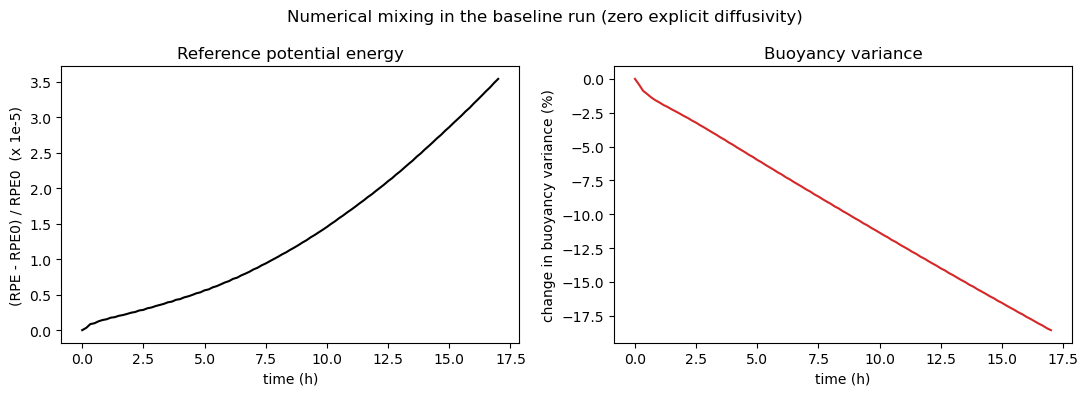

In [4]:
rpe = rpe_series(ds)
variance = buoyancy_variance(ds)
rpe_change = (rpe - rpe[0]) / rpe[0]
variance_change = (variance - variance[0]) / variance[0]
rate = rpe_rate_at(times, rpe, 17 * 3600, RATE_WINDOW) / LENGTH        # W per m^2 of channel floor
print(f"RPE at t = 0: {rpe[0]:.6e} J per metre of width")
print(f"normalized RPE change at 17 h: {rpe_change[-1]:.3e}")
print(f"dRPE/dt at 17 h (last hour): {rate:.3e} W/m^2")
print(f"buoyancy variance change at 17 h: {100 * variance_change[-1]:.2f}%")

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(times / 3600, rpe_change * 1e5, color="k")
axes[0].set_xlabel("time (h)")
axes[0].set_ylabel("(RPE - RPE0) / RPE0  (x 1e-5)")
axes[0].set_title("Reference potential energy")
axes[1].plot(times / 3600, 100 * variance_change, color="tab:red")
axes[1].set_xlabel("time (h)")
axes[1].set_ylabel("change in buoyancy variance (%)")
axes[1].set_title("Buoyancy variance")
fig.suptitle("Numerical mixing in the baseline run (zero explicit diffusivity)")
fig.tight_layout()
fig.savefig(os.path.join(FIG_DIR, "02_baseline_rpe_variance.png"), dpi=150)
plt.show()

## Sanity checks

1. Total buoyancy must stay constant (nothing enters or leaves): from the log, every 10 iterations.
2. RPE must never decrease (beyond round-off): the smallest change between snapshots.
3. A uniform passive tracer must stay exactly 1 (consistent advection), recorded by the run.
4. Overshoots: how far b went outside its starting range [0, 0.04905], also from the log.

In [5]:
total = log["b_total_m3_per_s2"]
drift = np.max(np.abs(total - total.iloc[0])) / total.iloc[0]
smallest_step = np.min(np.diff(rpe)) / rpe[0]
undershoot = -min(log["b_min"].min(), 0.0) / DELTA_B
overshoot = max(log["b_max"].max() - DELTA_B, 0.0) / DELTA_B
print(f"1. total buoyancy: largest relative change {drift:.2e}")
print(f"2. RPE: smallest change between snapshots {smallest_step:+.2e} of RPE0 "
      f"({'never decreases' if smallest_step >= 0 else 'DECREASES'})")
print(f"3. uniform tracer: largest deviation from 1 = {info['consistency_tracer_max_deviation']}")
print(f"4. b range {log['b_min'].min():.3e} to {log['b_max'].max():.6e}: undershoot {undershoot:.1e}, "
      f"overshoot {overshoot:.1e} of the buoyancy difference")
print(f"time step: largest {log['dt_s'].max():.1f} s (an explicit free surface would need < "
      f"{float(info['explicit_surface_wave_dt_limit_s']):.3f} s); largest advective CFL {log['advective_cfl'].max():.3f}")

pd.DataFrame({"time_s": times, "rpe_J_per_m": rpe, "rpe_change": rpe_change, "variance_change": variance_change,
              "front_right_m": right, "front_left_m": left}).to_csv(os.path.join(DATA_DIR, "step2_baseline_timeseries.csv"),
                                                                     index=False)
print("saved data/step2_baseline_timeseries.csv")

1. total buoyancy: largest relative change 1.83e-08
2. RPE: smallest change between snapshots +7.62e-08 of RPE0 (never decreases)
3. uniform tracer: largest deviation from 1 = 2.220e-16
4. b range -1.035e-05 to 4.906035e-02: undershoot 2.1e-04, overshoot 2.1e-04 of the buoyancy difference
time step: largest 43.9 s (an explicit free surface would need < 0.113 s); largest advective CFL 0.257
saved data/step2_baseline_timeseries.csv
